DATA LOCATION DIAGNOSTIC
[INFO] Loaded train_imputed.npy: shape=(4629, 21)
[INFO] Loaded scaler: mean shape=(15,)

[Row Counts]
  train:          4629
  train_imputed:  4629
  test_gt:        1158
  test_input:     1158
  WaveStitch+:    1158
  Final cleaned:     1158

[Observation Mask]
  Shape: (4629, 15)
  Observation rate: 100.00%
  train+test:     5787

[WaveStitch+ Alignment]
  ✓ Imputed is TEST data only

[Final cleaned Alignment]
  ✓ Imputed is TEST data only

GENERATING VISUALIZATIONS

[1] Data Layout Overview
[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/diagnostic_plots/data_layout_overview.png


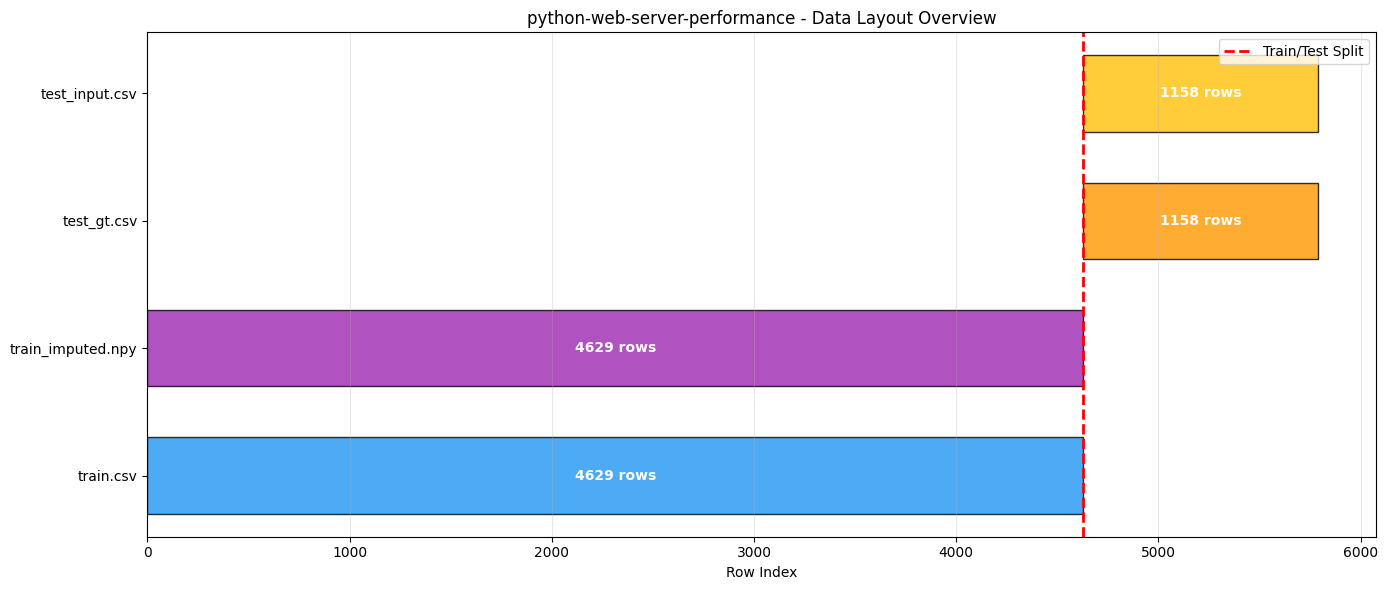


[2] Train Data Comparison (Original vs EM Imputed)

--- cpu_limit ---

[cpu_limit]
  Scaler: mean=1.4603, std=0.3382
  Original range: [0.9000, 2.0000]
  Imputed (norm) range: [-1.6569, 1.5958]
  Plot orig range: [0.9000, 2.0000]
  Plot imp range: [0.9000, 2.0000]
[SAVED] ./EUR/wavestitchplus/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/prepared/imputed_diagnosis/cpu_limit_comparison_original.png


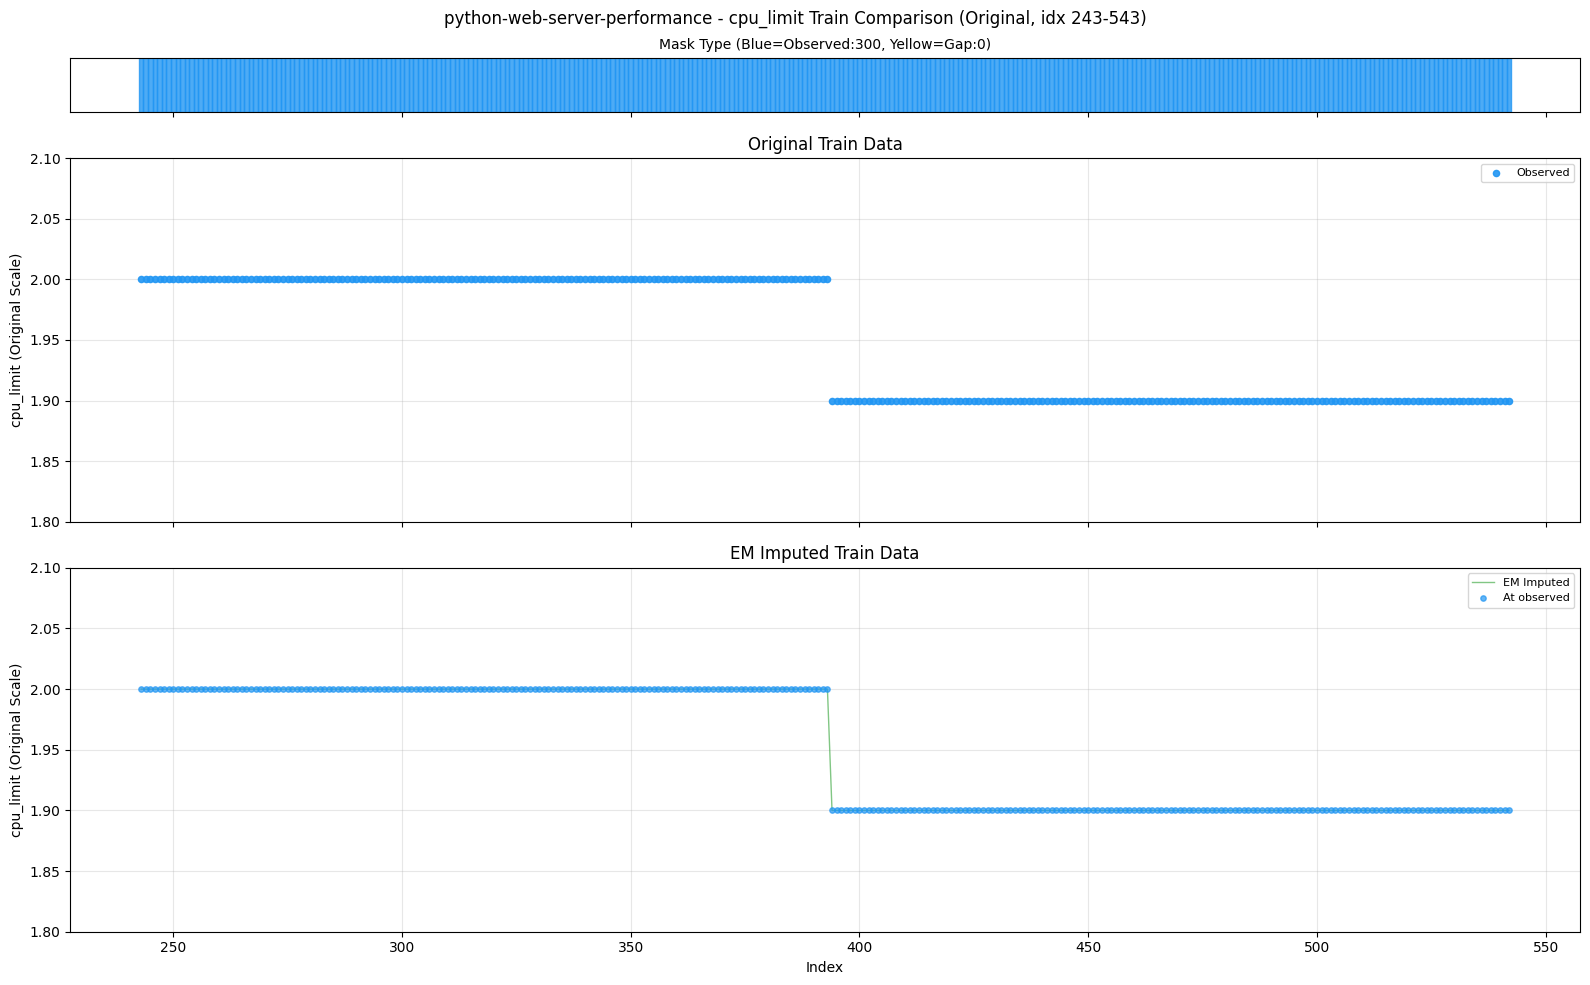

[SAVED] ./EUR/wavestitchplus/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/prepared/imputed_diagnosis/cpu_limit_overlay_orig.png


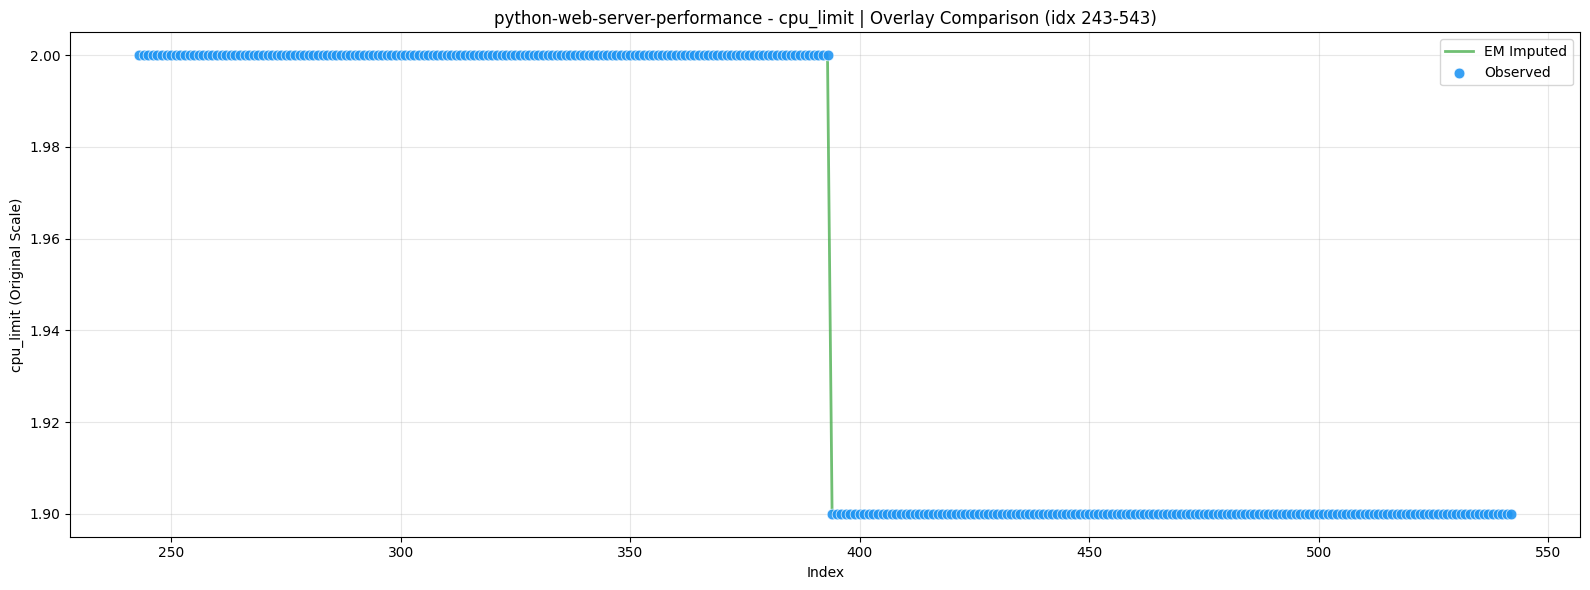

/home/Yuandou/miniconda3/envs/torchcuda/lib/python3.10/site-packages/numpy/lib/_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/diagnostic_plots/cpu_limit_train_distribution.png


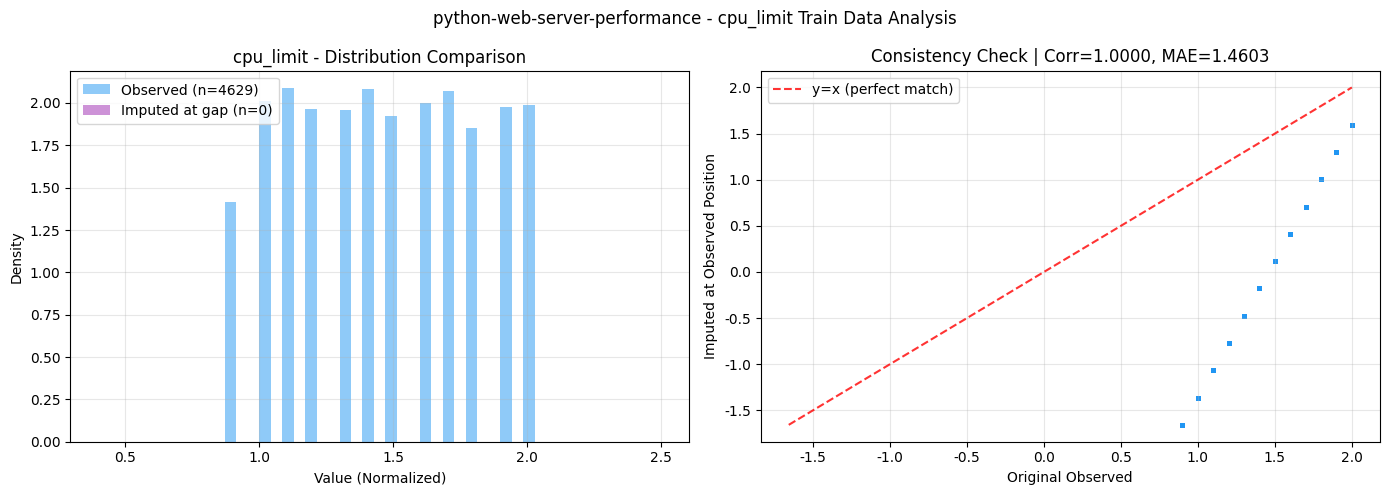

  [SKIP] cpu_limit: not enough gaps

--- cpu_usage ---

[cpu_usage]
  Scaler: mean=0.0133, std=0.0036
  Original range: [0.0000, 0.0192]
  Imputed (norm) range: [-3.0000, 1.6477]
  Plot orig range: [0.0000, 0.0192]
  Plot imp range: [0.0024, 0.0192]
[SAVED] ./EUR/wavestitchplus/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/prepared/imputed_diagnosis/cpu_usage_comparison_original.png


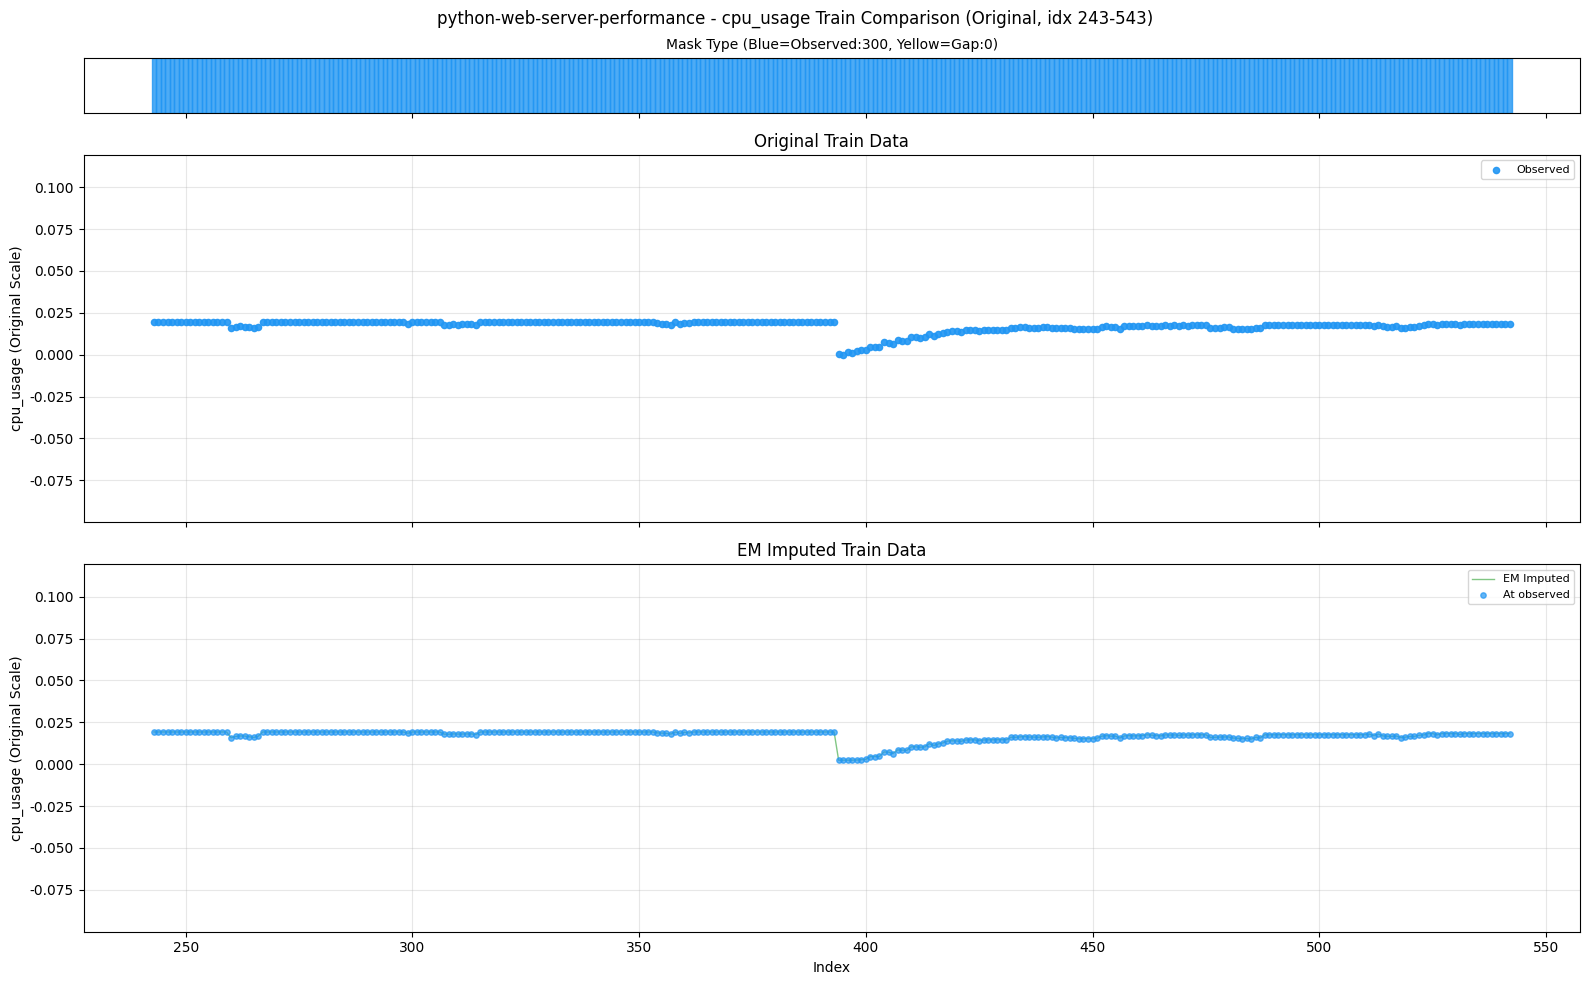

[SAVED] ./EUR/wavestitchplus/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/prepared/imputed_diagnosis/cpu_usage_overlay_orig.png


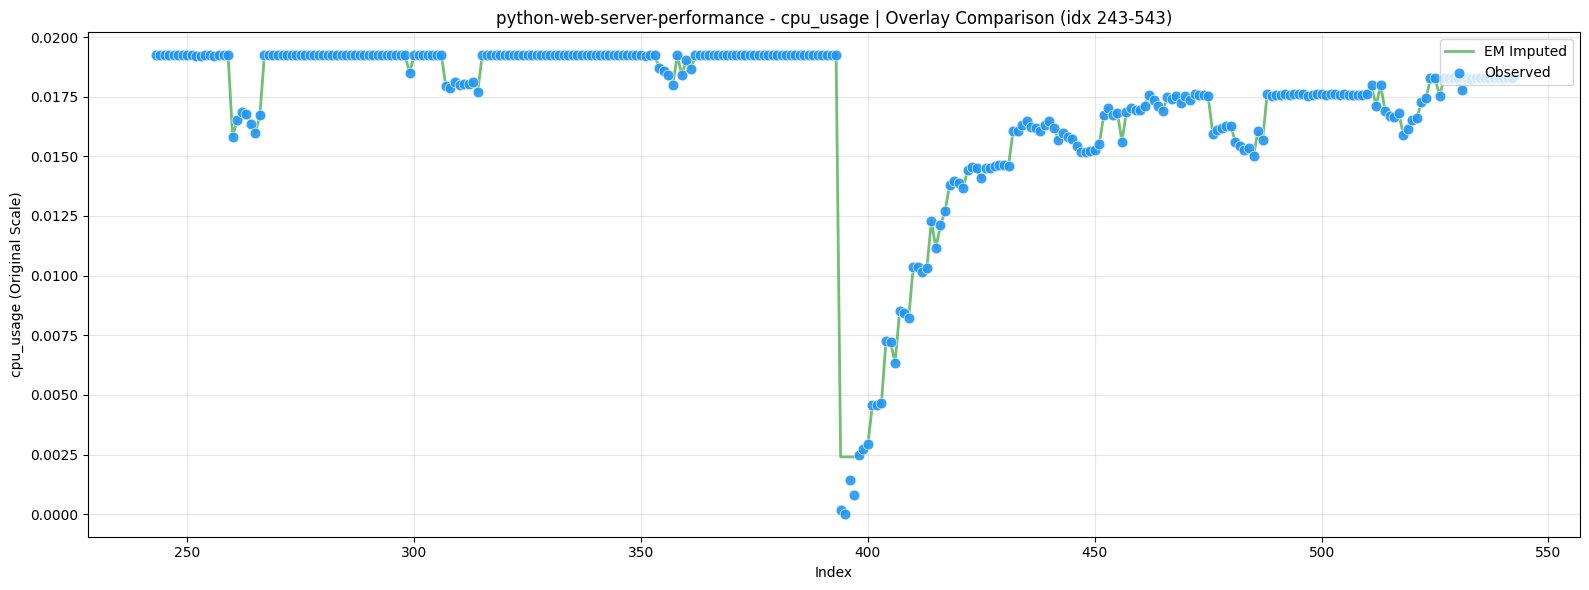

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/diagnostic_plots/cpu_usage_train_distribution.png


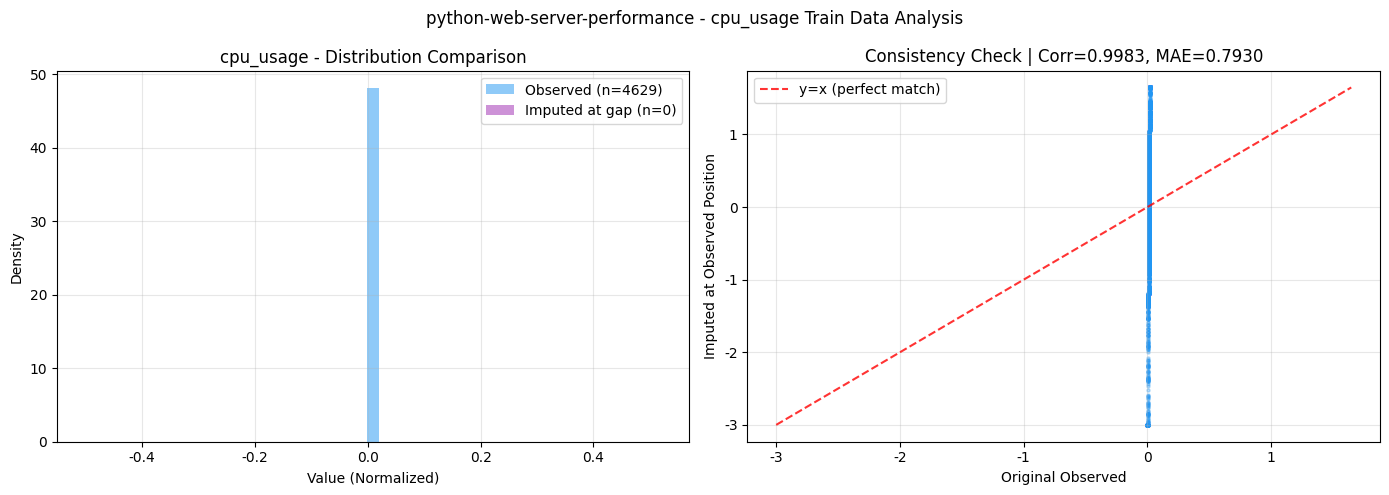

  [SKIP] cpu_usage: not enough gaps

--- n ---

[n]
  Scaler: mean=592.6766, std=266.4189
  Original range: [100.0000, 1000.0000]
  Imputed (norm) range: [-1.8493, 1.5289]
  Plot orig range: [100.0000, 1000.0000]
  Plot imp range: [100.0000, 1000.0000]
[SAVED] ./EUR/wavestitchplus/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/prepared/imputed_diagnosis/n_comparison_original.png


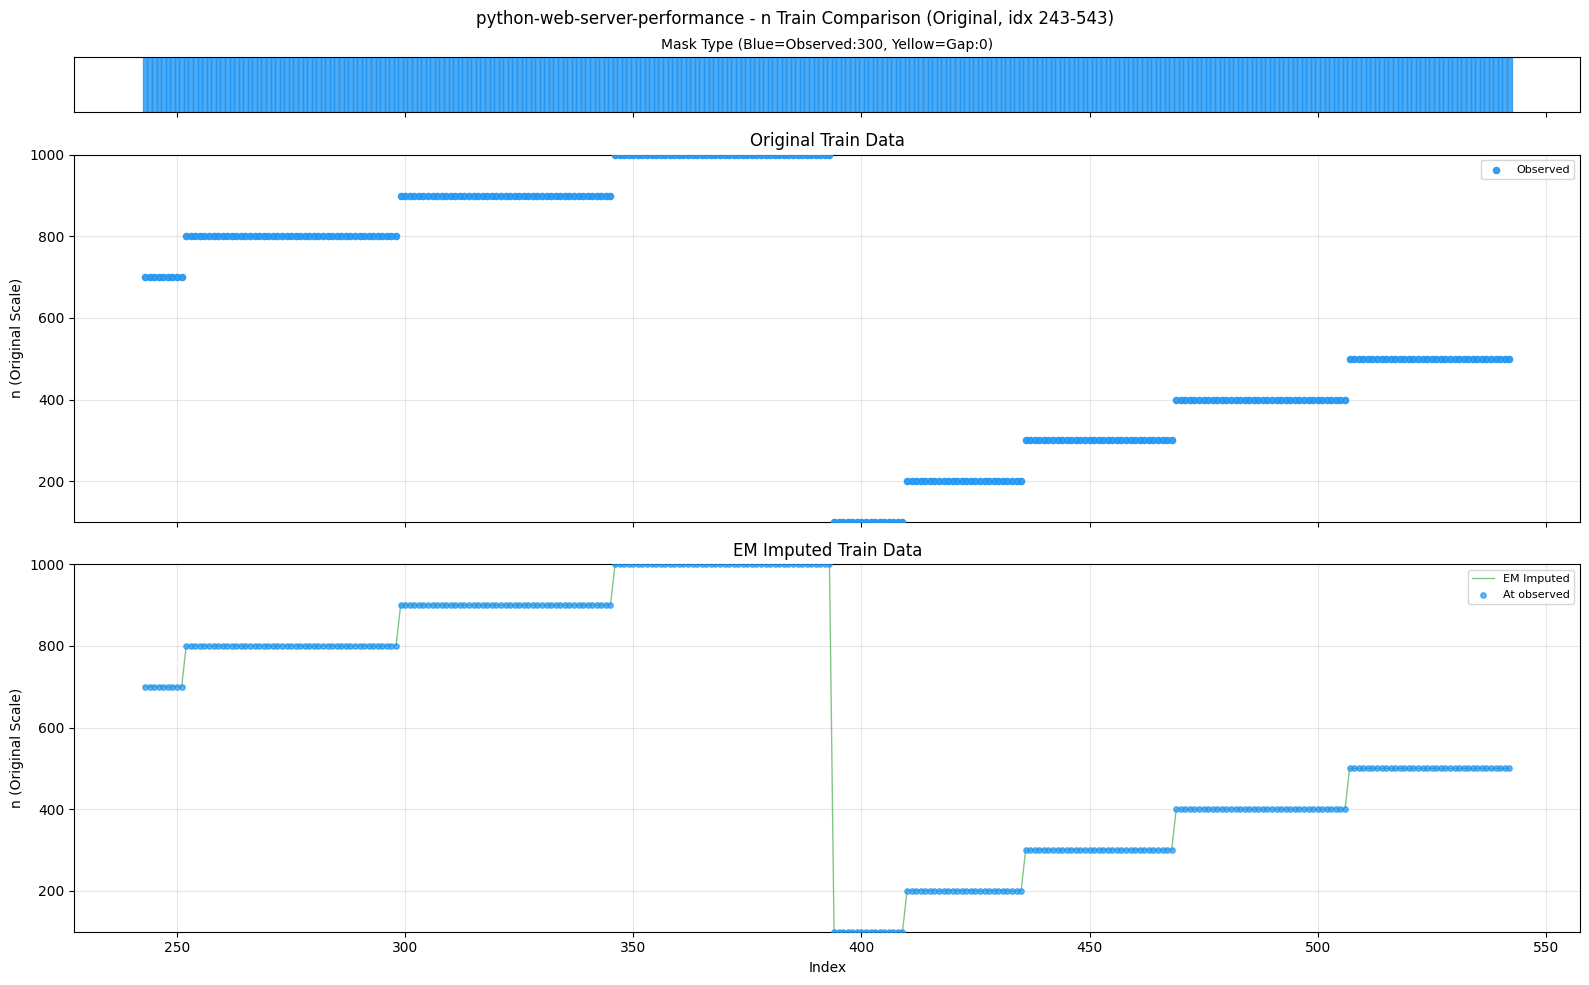

[SAVED] ./EUR/wavestitchplus/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/prepared/imputed_diagnosis/n_overlay_orig.png


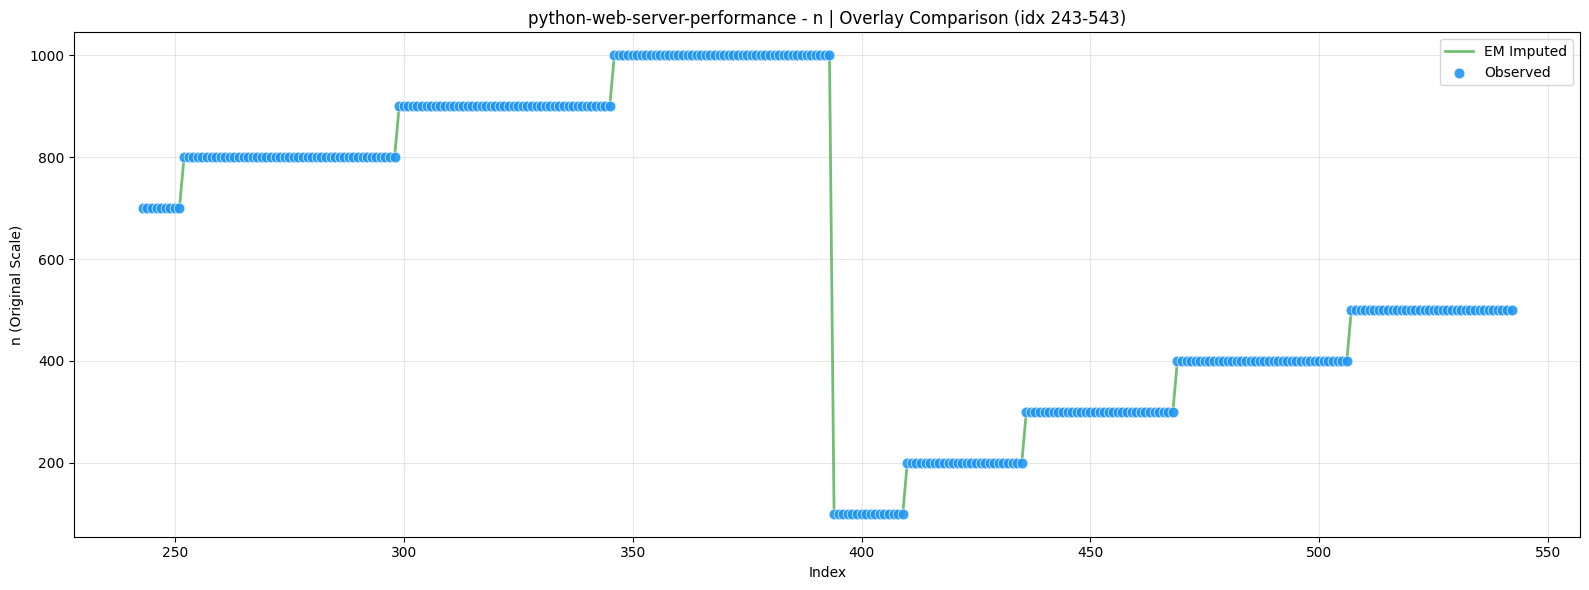

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/diagnostic_plots/n_train_distribution.png


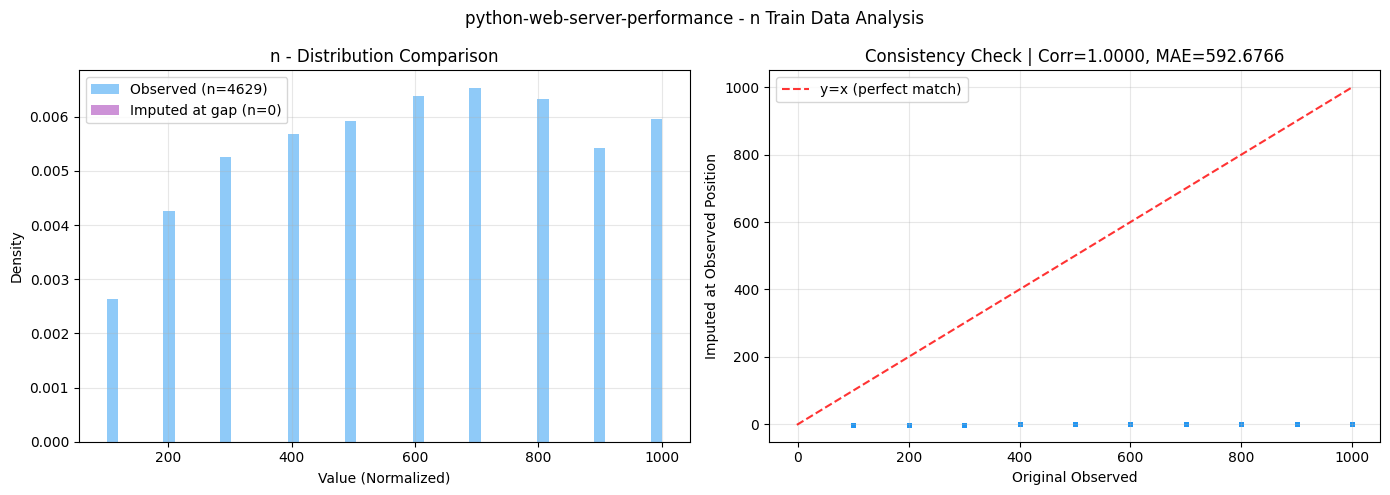

  [SKIP] n: not enough gaps

[3] Test and Full Data Comparison

--- cpu_limit ---
[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/diagnostic_plots/cpu_limit_data_overview.png


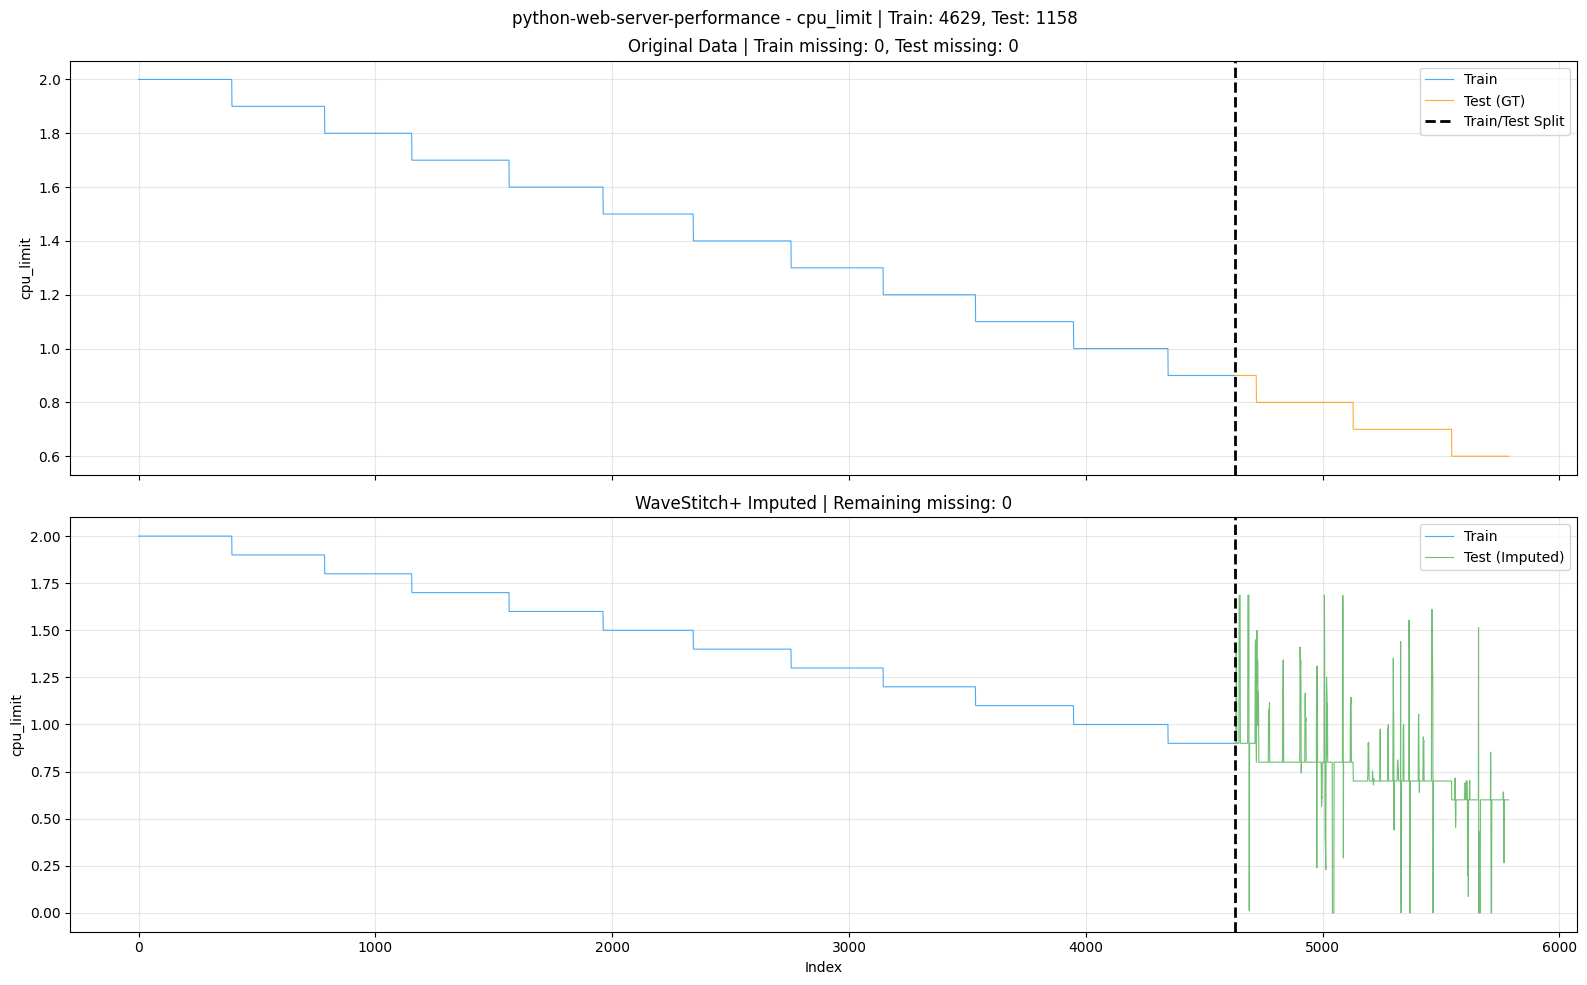

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/diagnostic_plots/cpu_limit_test_comparison.png


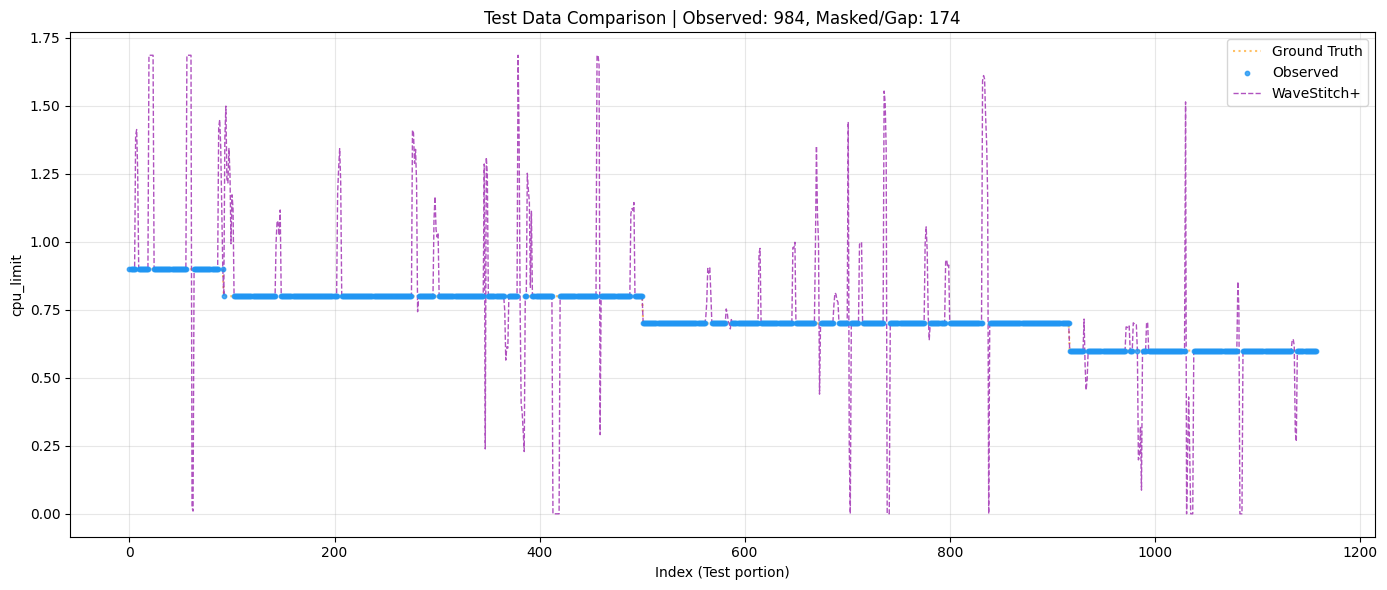


--- cpu_usage ---
[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/diagnostic_plots/cpu_usage_data_overview.png


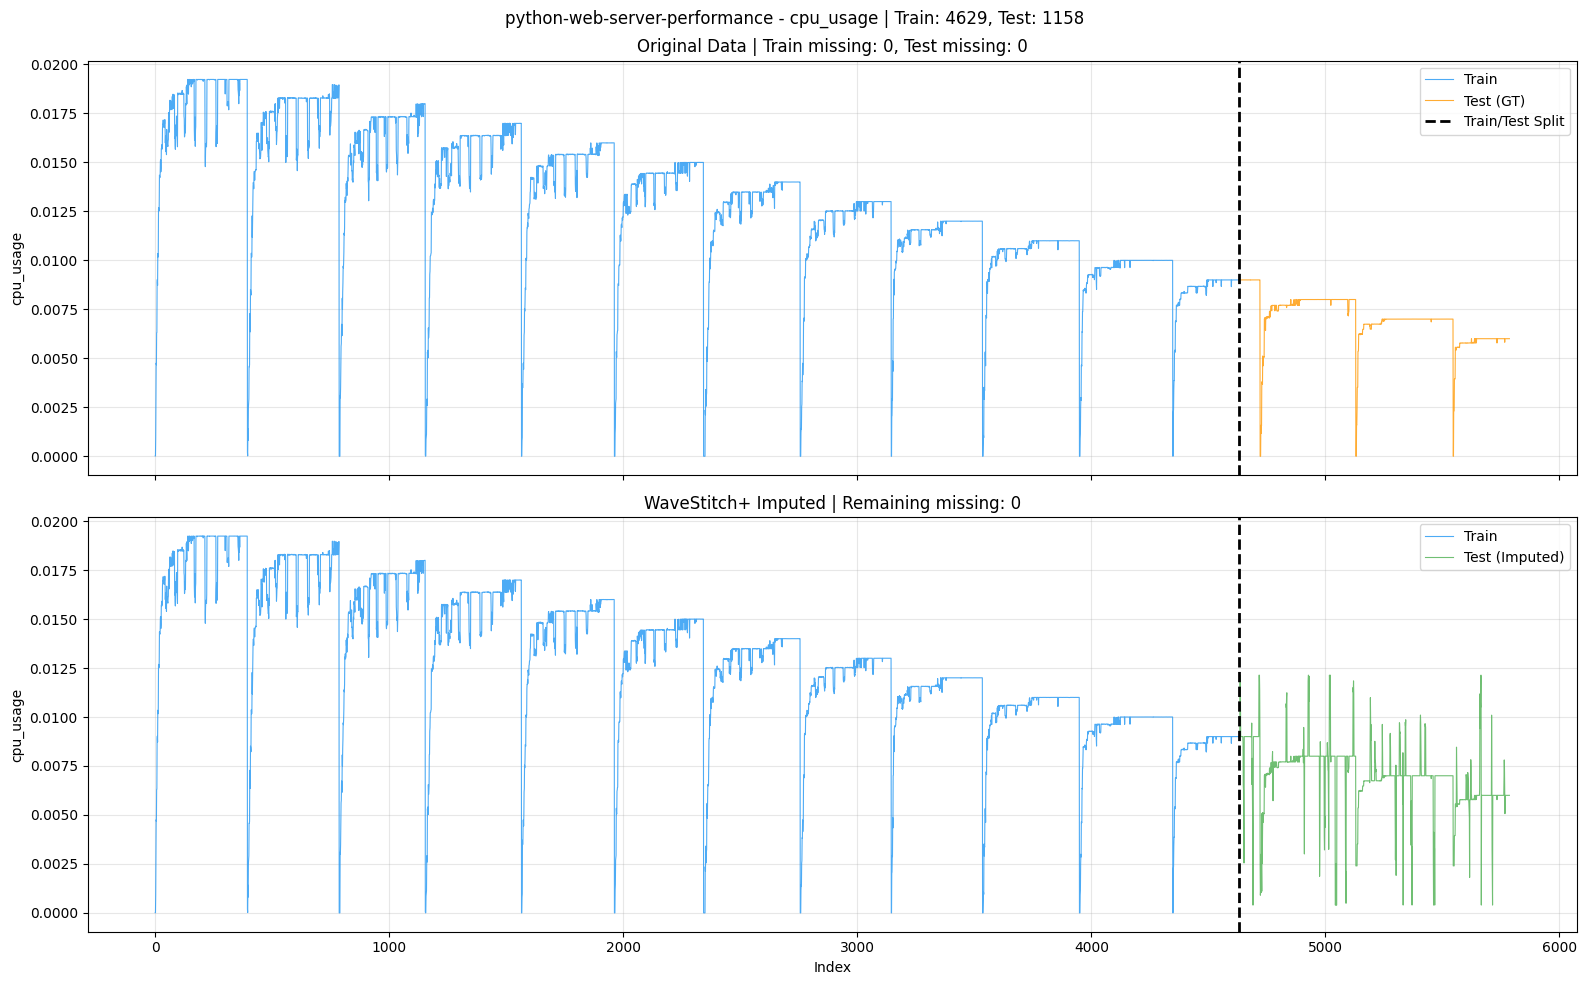

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/diagnostic_plots/cpu_usage_test_comparison.png


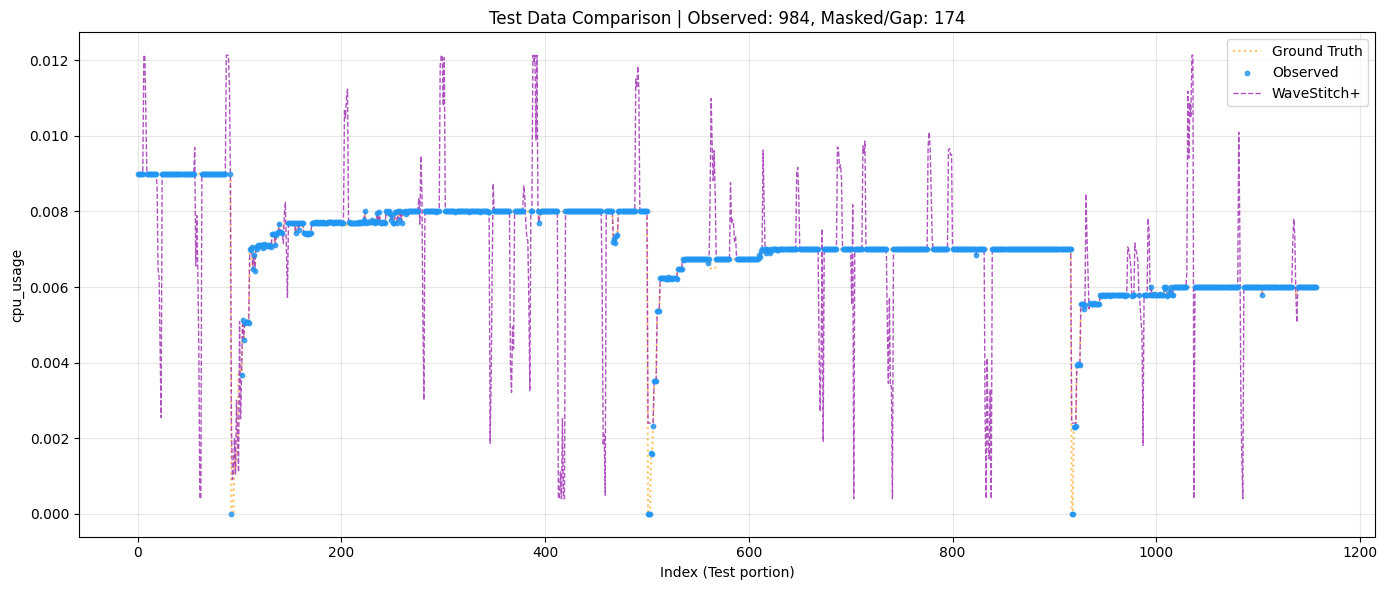


--- n ---
[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/diagnostic_plots/n_data_overview.png


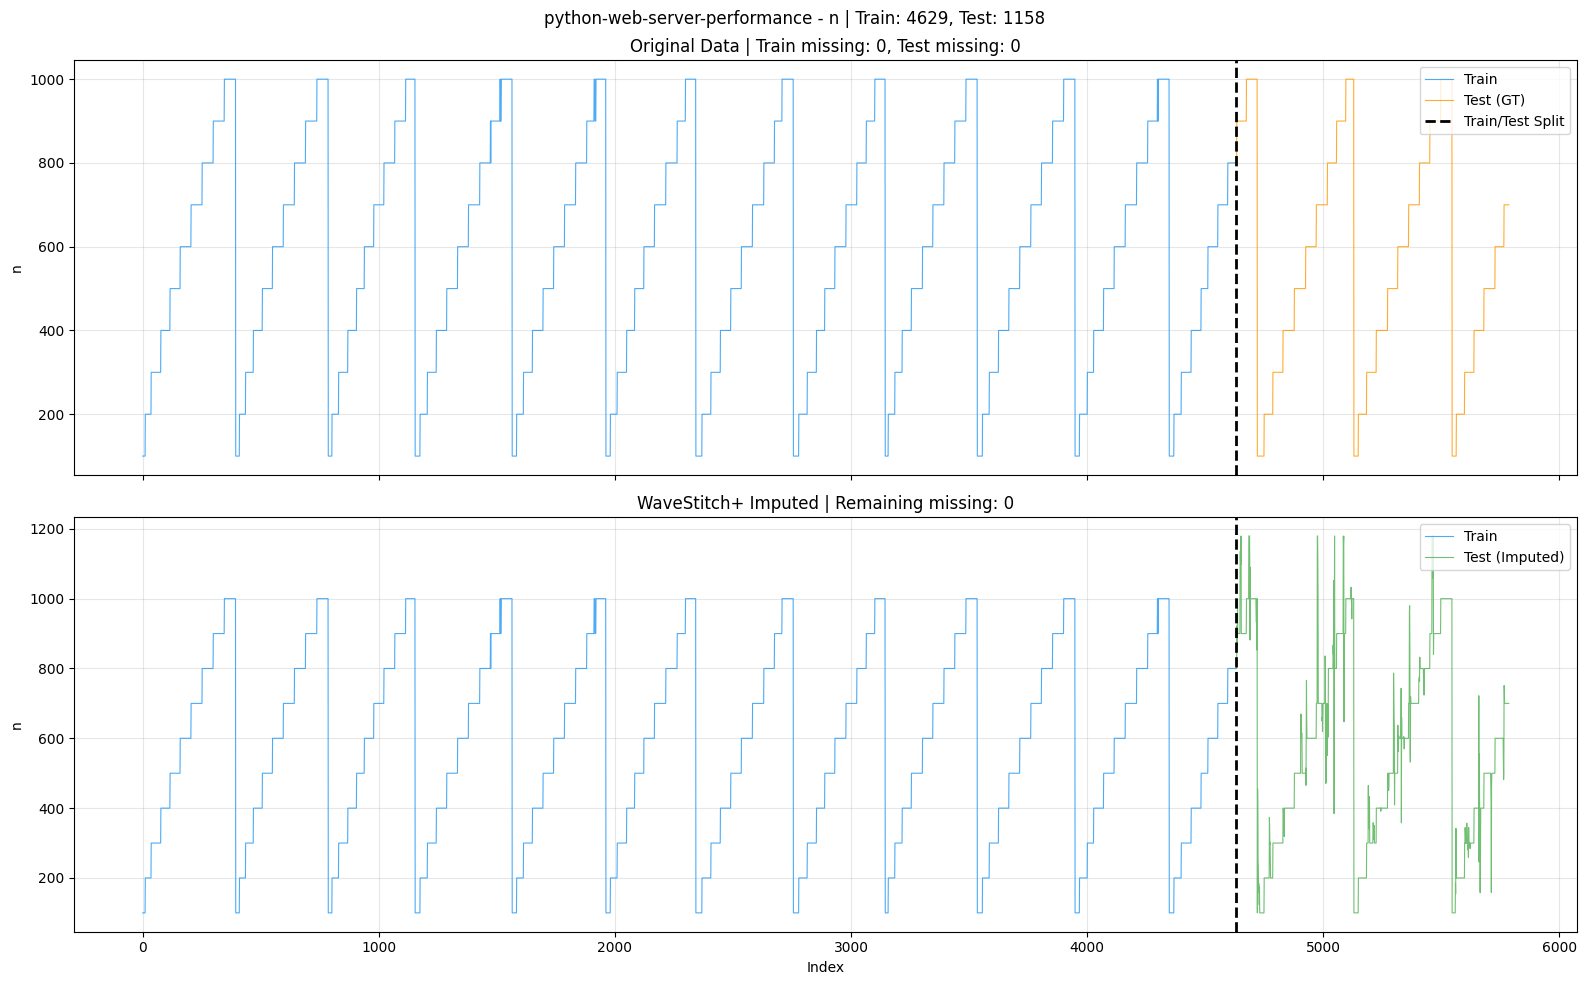

[SAVED] ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/diagnostic_plots/n_test_comparison.png


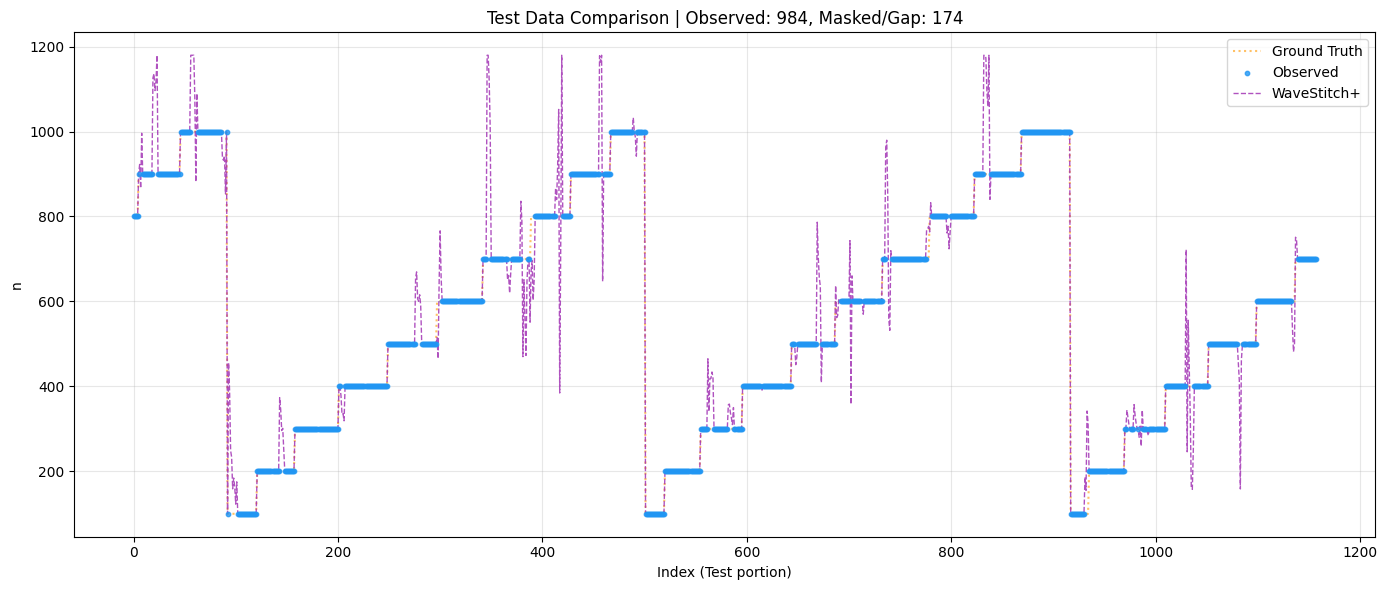


[DONE] All diagnostic plots saved to: ./EUR/curated/python-web-server-performance/manual__2026-02-25T09:30:58.766370+00:00/diagnostic_plots


In [5]:
"""
诊断 test_gt.csv 在原始数据中的位置 + 简单可视化
包含 train imputed 对比
"""

import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from datetime import datetime

# ============ 配置 ============
# datafilename = 'amf'
# base_dir = f'./work/EUR'
# prepared_dir = f'{base_dir}/prepared_{datafilename}'
# generated_dir = f'{base_dir}/generated_{datafilename}'

# ============ 配置 ============
datafilename = 'python-web-server-performance'
timeline = 'manual__2026-02-25T08:58:49.060878+00:00'
base_dir = f'./EUR'
# prepared_dir = f'{base_dir}/wavestitchplus/{datafilename}'
prepared_dir = f"{base_dir}/wavestitchplus/{datafilename}/{timeline}/prepared"
generated_dir = f'{base_dir}/curated/{datafilename}/{timeline}/'
final_cleaned_dir = f'{base_dir}/cleaned/{datafilename}/{timeline}/'


plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# ============ 修复版对比函数 ============
def plot_train_comparison(feature_name, window_size=300, center_idx=None, 
                                 use_normalized=False, save=True):
    """
    修复版：确保原始数据和 Imputed 使用相同尺度
    
    Args:
        use_normalized: True=两者都用标准化值，False=两者都用原始值
    """
    if feature_name not in target_cols:
        print(f"[SKIP] {feature_name} not in target_cols")
        return
    
    col_idx = model_cols.index(feature_name)
    target_col_idx = target_cols.index(feature_name)
    
    # 原始数据
    orig_col = train_data[feature_name].values.copy()
    obs_col_mask = obs_mask[:, target_col_idx].astype(bool)
    missing_mask = ~obs_col_mask
    
    # Imputed 数据（标准化空间）
    imp_col_normalized = train_imputed[:, col_idx].copy()
    
    # 获取该列的 scaler 参数
    col_mean = scaler_mean[target_col_idx]
    col_std = scaler_std[target_col_idx]
    
    print(f"\n[{feature_name}]")
    print(f"  Scaler: mean={col_mean:.4f}, std={col_std:.4f}")
    print(f"  Original range: [{np.nanmin(orig_col):.4f}, {np.nanmax(orig_col):.4f}]")
    print(f"  Imputed (norm) range: [{imp_col_normalized.min():.4f}, {imp_col_normalized.max():.4f}]")
    
    if use_normalized:
        # 将原始数据标准化
        orig_col_plot = (orig_col - col_mean) / (col_std + 1e-12)
        orig_col_plot = np.clip(orig_col_plot, -3.0, 3.0)
        imp_col_plot = imp_col_normalized
        ylabel = f'{feature_name} (Normalized)'
    else:
        # 将 Imputed 数据逆标准化
        orig_col_plot = orig_col
        imp_col_plot = imp_col_normalized * (col_std + 1e-12) + col_mean
        ylabel = f'{feature_name} (Original Scale)'
    
    print(f"  Plot orig range: [{np.nanmin(orig_col_plot):.4f}, {np.nanmax(orig_col_plot):.4f}]")
    print(f"  Plot imp range: [{imp_col_plot.min():.4f}, {imp_col_plot.max():.4f}]")
    
    # 确定显示范围
    if center_idx is None:
        # 找有变化的区域（而不是缺失区域）
        diff = np.abs(np.diff(orig_col_plot[obs_col_mask]))
        if len(diff) > 0:
            # 找最大变化点
            obs_indices = np.where(obs_col_mask)[0]
            max_diff_idx = np.argmax(diff)
            center_idx = obs_indices[max_diff_idx]
        else:
            center_idx = len(orig_col) // 2
    
    start_idx = max(0, center_idx - window_size // 2)
    end_idx = min(len(orig_col), center_idx + window_size // 2)
    
    idx_range = slice(start_idx, end_idx)
    x_range = np.arange(start_idx, end_idx)
    
    orig_slice = orig_col_plot[idx_range]
    obs_slice = obs_col_mask[idx_range]
    miss_slice = ~obs_slice
    imp_slice = imp_col_plot[idx_range]
    
    # 创建图
    fig, axes = plt.subplots(3, 1, figsize=(16, 10), 
                              gridspec_kw={'height_ratios': [0.3, 2, 2]}, sharex=True)
    
    # === 子图1: Mask 类型条 ===
    ax_mask = axes[0]
    for i, x in enumerate(x_range):
        color = '#2196F3' if obs_slice[i] else '#FFEB3B'
        ax_mask.axvspan(x - 0.5, x + 0.5, alpha=0.8, color=color)
    
    ax_mask.set_ylim(0, 1)
    ax_mask.set_yticks([])
    n_obs = obs_slice.sum()
    n_miss = miss_slice.sum()
    ax_mask.set_title(f'Mask Type (Blue=Observed:{n_obs}, Yellow=Gap:{n_miss})', fontsize=10)
    
    # === 子图2: 原始数据 ===
    ax1 = axes[1]
    
    # 背景高亮缺失区域
    for i, x in enumerate(x_range):
        if miss_slice[i]:
            ax1.axvspan(x - 0.5, x + 0.5, alpha=0.15, color='red')
    
    # 观测值
    if obs_slice.any():
        valid_obs = ~np.isnan(orig_slice[obs_slice])
        ax1.scatter(x_range[obs_slice][valid_obs], orig_slice[obs_slice][valid_obs], 
                   s=20, color='#2196F3', alpha=0.9, 
                   label='Observed', zorder=5, marker='o')
    
    ax1.set_ylabel(ylabel)
    ax1.set_title(f'Original Train Data')
    ax1.legend(loc='upper right', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # === 子图3: Imputed 数据 ===
    ax2 = axes[2]
    
    # 背景高亮缺失区域
    for i, x in enumerate(x_range):
        if miss_slice[i]:
            ax2.axvspan(x - 0.5, x + 0.5, alpha=0.15, color='green')
    
    # Imputed 完整线
    ax2.plot(x_range, imp_slice, color='#4CAF50', alpha=0.7, 
             linewidth=1, label='EM Imputed')
    
    # 观测位置
    if obs_slice.any():
        ax2.scatter(x_range[obs_slice], imp_slice[obs_slice], 
                   s=15, color='#2196F3', alpha=0.7, 
                   label='At observed', zorder=4, marker='o')
    
    # Imputed 位置
    if miss_slice.any():
        ax2.scatter(x_range[miss_slice], imp_slice[miss_slice], 
                   s=25, color='#9C27B0', alpha=0.9, 
                   label='At gap', zorder=5, marker='s',
                   edgecolors='black', linewidth=0.5)
    
    ax2.set_ylabel(ylabel)
    ax2.set_xlabel('Index')
    ax2.set_title(f'EM Imputed Train Data')
    ax2.legend(loc='upper right', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # 🔥 关键：设置相同的 y 轴范围
    y_min = min(np.nanmin(orig_slice), np.nanmin(imp_slice)) - 0.1
    y_max = max(np.nanmax(orig_slice), np.nanmax(imp_slice)) + 0.1
    ax1.set_ylim(y_min, y_max)
    ax2.set_ylim(y_min, y_max)
    
    scale_str = 'Normalized' if use_normalized else 'Original'
    plt.suptitle(f'{datafilename} - {feature_name} Train Comparison ({scale_str}, idx {start_idx}-{end_idx})', 
                 fontsize=12)
    plt.tight_layout()
    
    if save:
        output_dir = os.path.join(prepared_dir, 'imputed_diagnosis')
        os.makedirs(output_dir, exist_ok=True)
        save_path = os.path.join(output_dir, f'{feature_name}_comparison_{scale_str.lower()}.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"[SAVED] {save_path}")
    
    plt.show()
    plt.close()


def plot_train_comparison_overlay(feature_name, window_size=300, center_idx=None, 
                       use_normalized=False, save=True):
    """
    单图叠加对比（修复版）
    """
    if feature_name not in target_cols:
        print(f"[SKIP] {feature_name} not in target_cols")
        return
    
    col_idx = model_cols.index(feature_name)
    target_col_idx = target_cols.index(feature_name)
    
    orig_col = train_data[feature_name].values.copy()
    obs_col_mask = obs_mask[:, target_col_idx].astype(bool)
    imp_col_normalized = train_imputed[:, col_idx].copy()
    
    col_mean = scaler_mean[target_col_idx]
    col_std = scaler_std[target_col_idx]
    
    if use_normalized:
        orig_col_plot = (orig_col - col_mean) / (col_std + 1e-12)
        orig_col_plot = np.clip(orig_col_plot, -3.0, 3.0)
        imp_col_plot = imp_col_normalized
        ylabel = f'{feature_name} (Normalized)'
    else:
        orig_col_plot = orig_col
        imp_col_plot = imp_col_normalized * (col_std + 1e-12) + col_mean
        ylabel = f'{feature_name} (Original Scale)'
    
    # 找变化点
    if center_idx is None:
        valid_orig = orig_col_plot[obs_col_mask]
        valid_orig = valid_orig[~np.isnan(valid_orig)]
        if len(valid_orig) > 1:
            diff = np.abs(np.diff(valid_orig))
            obs_indices = np.where(obs_col_mask)[0]
            valid_indices = obs_indices[~np.isnan(orig_col_plot[obs_col_mask])]
            if len(diff) > 0 and len(valid_indices) > 1:
                max_idx = np.argmax(diff)
                center_idx = valid_indices[min(max_idx, len(valid_indices)-1)]
            else:
                center_idx = len(orig_col) // 2
        else:
            center_idx = len(orig_col) // 2
    
    start_idx = max(0, center_idx - window_size // 2)
    end_idx = min(len(orig_col), center_idx + window_size // 2)
    
    x_range = np.arange(start_idx, end_idx)
    orig_slice = orig_col_plot[start_idx:end_idx]
    obs_slice = obs_col_mask[start_idx:end_idx]
    miss_slice = ~obs_slice
    imp_slice = imp_col_plot[start_idx:end_idx]
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # 背景
    for i, x in enumerate(x_range):
        if miss_slice[i]:
            ax.axvspan(x - 0.5, x + 0.5, alpha=0.15, color='orange')
    
    # Imputed 线
    ax.plot(x_range, imp_slice, color='#4CAF50', alpha=0.8, 
            linewidth=2, label='EM Imputed', zorder=2)
    
    # 观测值点
    if obs_slice.any():
        valid_mask = ~np.isnan(orig_slice[obs_slice])
        ax.scatter(x_range[obs_slice][valid_mask], orig_slice[obs_slice][valid_mask], 
                   s=60, color='#2196F3', alpha=0.9, 
                   label='Observed', zorder=5, marker='o',
                   edgecolors='white', linewidth=0.5)
    
    # Imputed at gap 点
    if miss_slice.any():
        ax.scatter(x_range[miss_slice], imp_slice[miss_slice], 
                   s=40, color='#9C27B0', alpha=0.9, 
                   label='Imputed (at gap)', zorder=4, marker='s',
                   edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel('Index')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{datafilename} - {feature_name} | Overlay Comparison (idx {start_idx}-{end_idx})')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save:
        output_dir = os.path.join(prepared_dir, 'imputed_diagnosis')
        os.makedirs(output_dir, exist_ok=True)
        scale_str = 'norm' if use_normalized else 'orig'
        save_path = os.path.join(output_dir, f'{feature_name}_overlay_{scale_str}.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"[SAVED] {save_path}")
    
    plt.show()
    plt.close()


def check_consistency(feature_name):
    """
    检查观测位置的一致性
    """
    if feature_name not in target_cols:
        return
    
    col_idx = model_cols.index(feature_name)
    target_col_idx = target_cols.index(feature_name)
    
    orig_col = train_data[feature_name].values.copy()
    obs_col_mask = obs_mask[:, target_col_idx].astype(bool)
    imp_col = train_imputed[:, col_idx]
    
    col_mean = scaler_mean[target_col_idx]
    col_std = scaler_std[target_col_idx]
    
    # 标准化原始值
    orig_normalized = (orig_col - col_mean) / (col_std + 1e-12)
    orig_normalized = np.clip(orig_normalized, -3.0, 3.0)
    
    # 观测位置对比
    orig_at_obs = orig_normalized[obs_col_mask]
    imp_at_obs = imp_col[obs_col_mask]
    
    valid = ~np.isnan(orig_at_obs)
    orig_at_obs = orig_at_obs[valid]
    imp_at_obs = imp_at_obs[valid]
    
    diff = np.abs(orig_at_obs - imp_at_obs)
    
    print(f"\n[{feature_name}] 一致性检查:")
    print(f"  观测点数: {len(orig_at_obs)}")
    print(f"  原始(norm) 范围: [{orig_at_obs.min():.4f}, {orig_at_obs.max():.4f}]")
    print(f"  Imputed 范围: [{imp_at_obs.min():.4f}, {imp_at_obs.max():.4f}]")
    print(f"  差异: mean={diff.mean():.6f}, max={diff.max():.6f}")
    
    if diff.max() > 0.01:
        print(f"  ⚠ 警告: 观测值被修改了!")
        
        # 找出差异最大的位置
        max_diff_idx = np.argmax(diff)
        print(f"  最大差异位置: idx={np.where(obs_col_mask)[0][valid][max_diff_idx]}")
        print(f"    原始值: {orig_at_obs[max_diff_idx]:.4f}")
        print(f"    Imputed: {imp_at_obs[max_diff_idx]:.4f}")
    else:
        print(f"  ✓ 观测值保持一致")



# ============ 加载 meta ============
meta_path = os.path.join(prepared_dir, 'meta.json')
with open(meta_path, 'r') as f:
    meta = json.load(f)

time_col = meta.get('time_col', 'time')
target_cols = meta.get('target_cols', [])
cond_cols = meta.get('cond_cols', [])
all_model_cols = meta.get('all_model_cols', [])

print(f"{'='*70}")
print(f"DATA LOCATION DIAGNOSTIC")
print(f"{'='*70}")

# ============ 加载所有数据 ============
train_df = pd.read_csv(os.path.join(prepared_dir, 'train.csv'))
test_gt = pd.read_csv(os.path.join(prepared_dir, 'test_gt.csv'))
test_input = pd.read_csv(os.path.join(prepared_dir, 'test_input.csv'))

# 加载 train_imputed.npy（EM 训练的 imputed 数据）
train_imputed_path = os.path.join(prepared_dir, 'train_imputed.npy')
train_imputed = None
if os.path.exists(train_imputed_path):
    train_imputed = np.load(train_imputed_path)
    print(f"[INFO] Loaded train_imputed.npy: shape={train_imputed.shape}")
else:
    print(f"[WARNING] train_imputed.npy not found")

# 加载 scaler
scaler_dir = os.path.join(prepared_dir, 'scaler')
scaler_mean = None
scaler_std = None
if os.path.exists(os.path.join(scaler_dir, 'mean.npy')):
    scaler_mean = np.load(os.path.join(scaler_dir, 'mean.npy'))
    scaler_std = np.load(os.path.join(scaler_dir, 'std.npy'))
    print(f"[INFO] Loaded scaler: mean shape={scaler_mean.shape}")

# 加载 generated 数据
fc_path = os.path.join(final_cleaned_dir, 'cleaned.csv')
wsp_path = os.path.join(generated_dir, 'data.csv')

pred_wavestitchPlus = pd.read_csv(wsp_path) if os.path.exists(wsp_path) else None
final_cleaned = pd.read_csv(fc_path) if os.path.exists(fc_path) else None

print(f"\n[Row Counts]")
print(f"  train:          {len(train_df)}")
print(f"  train_imputed:  {train_imputed.shape[0] if train_imputed is not None else 'N/A'}")
print(f"  test_gt:        {len(test_gt)}")
print(f"  test_input:     {len(test_input)}")

print(f"  WaveStitch+:    {len(pred_wavestitchPlus) if pred_wavestitchPlus is not None else 'N/A'}")
print(f"  Final cleaned:     {len(final_cleaned) if final_cleaned is not None else 'N/A'}")
# ============ 获取 model columns ============
if all_model_cols:
    model_cols = all_model_cols
else:
    model_cols = [c for c in train_df.columns if c != time_col]

# 获取 target 列索引
target_indices = [model_cols.index(c) for c in target_cols if c in model_cols]

# ============ 构建观测掩码 ============
train_data = train_df.drop(columns=[time_col], errors='ignore')
train_data = train_data[model_cols]
obs_mask = (~train_data[target_cols].isna()).values.astype(np.float32)

print(f"\n[Observation Mask]")
print(f"  Shape: {obs_mask.shape}")
print(f"  Observation rate: {obs_mask.mean():.2%}")

# ============ 拼接原始 train + test ============
original_full = pd.concat([train_df, test_gt], ignore_index=True)
print(f"  train+test:     {len(original_full)}")

# ============ 检查 imputed 数据对齐 ============
def check_and_align(imputed_df, original_full, train_df, test_df, name):
    """检查并对齐 imputed 数据"""
    if imputed_df is None:
        return None, None
    
    print(f"\n[{name} Alignment]")
    
    if len(imputed_df) == len(original_full):
        print(f"  ✓ Imputed is FULL data (train + test)")
        imputed_test = imputed_df.iloc[len(train_df):].reset_index(drop=True)
        return imputed_df, imputed_test
    
    elif len(imputed_df) == len(test_df):
        print(f"  ✓ Imputed is TEST data only")
        imputed_full = pd.concat([train_df, imputed_df], ignore_index=True)
        return imputed_full, imputed_df
    
    else:
        print(f"  ✗ Unknown format: {len(imputed_df)} rows")
        return None, None

wsp_full, wsp_test = check_and_align(pred_wavestitchPlus, original_full, train_df, test_input, "WaveStitch+")
fc_full, fc_test = check_and_align(final_cleaned, original_full, train_df, test_input, "Final cleaned")
# ============ 颜色定义 ============
COLORS = {
    'observed': '#2196F3',      # 蓝色
    'gap': '#FFEB3B',           # 黄色
    'train': '#2196F3',         # 蓝色
    'test': '#FF9800',          # 橙色
    'imputed': '#4CAF50',       # 绿色
    'imputed_em': '#9C27B0',    # 紫色
    'gt': '#607D8B',            # 灰色
}

# ============ 输出目录 ============
output_dir = os.path.join(generated_dir, 'diagnostic_plots')
os.makedirs(output_dir, exist_ok=True)


def plot_train_distribution(feature_name, save=True):
    """
    对比训练数据分布：观测值 vs Imputed at gap
    """
    if feature_name not in target_cols:
        print(f"[SKIP] {feature_name} not in target_cols")
        return
    
    if train_imputed is None:
        print(f"[SKIP] train_imputed not available")
        return
    
    col_idx = model_cols.index(feature_name)
    target_col_idx = target_cols.index(feature_name)
    
    orig_col = train_data[feature_name].values
    obs_col_mask = obs_mask[:, target_col_idx].astype(bool)
    imp_col = train_imputed[:, col_idx]
    
    # 观测值
    observed_vals = orig_col[obs_col_mask]
    observed_vals = observed_vals[~np.isnan(observed_vals)]
    
    # Imputed at gap
    imputed_at_gap = imp_col[~obs_col_mask]
    
    # Imputed at observed (应该与原始相近)
    imputed_at_obs = imp_col[obs_col_mask]
    
    # 创建图
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # === 左图：分布对比 ===
    ax1 = axes[0]
    
    # 确定 bins
    all_vals = np.concatenate([observed_vals, imputed_at_gap])
    bins = np.linspace(all_vals.min() - 0.5, all_vals.max() + 0.5, 50)
    
    ax1.hist(observed_vals, bins=bins, alpha=0.5, color=COLORS['observed'], 
             label=f'Observed (n={len(observed_vals)})', density=True)
    ax1.hist(imputed_at_gap, bins=bins, alpha=0.5, color=COLORS['imputed_em'], 
             label=f'Imputed at gap (n={len(imputed_at_gap)})', density=True)
    
    ax1.set_xlabel('Value (Normalized)')
    ax1.set_ylabel('Density')
    ax1.set_title(f'{feature_name} - Distribution Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # === 右图：观测位置一致性检查 ===
    ax2 = axes[1]
    
    # 观测位置：原始 vs Imputed（应该几乎相同）
    ax2.scatter(observed_vals, imputed_at_obs, s=5, alpha=0.3, color=COLORS['observed'])
    
    # 对角线
    lims = [min(observed_vals.min(), imputed_at_obs.min()),
            max(observed_vals.max(), imputed_at_obs.max())]
    ax2.plot(lims, lims, 'r--', alpha=0.8, label='y=x (perfect match)')
    
    # 计算相关性
    corr = np.corrcoef(observed_vals, imputed_at_obs)[0, 1]
    mae = np.mean(np.abs(observed_vals - imputed_at_obs))
    
    ax2.set_xlabel('Original Observed')
    ax2.set_ylabel('Imputed at Observed Position')
    ax2.set_title(f'Consistency Check | Corr={corr:.4f}, MAE={mae:.4f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle(f'{datafilename} - {feature_name} Train Data Analysis', fontsize=12)
    plt.tight_layout()
    
    if save:
        save_path = os.path.join(output_dir, f'{feature_name}_train_distribution.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"[SAVED] {save_path}")
    
    plt.show()
    plt.close()


def plot_train_multi_windows(feature_name, n_windows=4, window_size=150, save=True):
    """
    多窗口对比训练数据
    """
    if feature_name not in target_cols:
        print(f"[SKIP] {feature_name} not in target_cols")
        return
    
    if train_imputed is None:
        print(f"[SKIP] train_imputed not available")
        return
    
    col_idx = model_cols.index(feature_name)
    target_col_idx = target_cols.index(feature_name)
    
    orig_col = train_data[feature_name].values
    obs_col_mask = obs_mask[:, target_col_idx].astype(bool)
    missing_mask = ~obs_col_mask
    imp_col = train_imputed[:, col_idx]
    
    # 找缺失位置
    missing_indices = np.where(missing_mask)[0]
    if len(missing_indices) < n_windows:
        print(f"  [SKIP] {feature_name}: not enough gaps")
        return
    
    # 均匀选择窗口中心
    selected = np.linspace(0, len(missing_indices) - 1, n_windows, dtype=int)
    centers = [missing_indices[i] for i in selected]
    
    fig, axes = plt.subplots(n_windows, 1, figsize=(16, 3 * n_windows))
    
    for ax_idx, center in enumerate(centers):
        ax = axes[ax_idx]
        
        start_idx = max(0, center - window_size // 2)
        end_idx = min(len(orig_col), center + window_size // 2)
        
        idx_range = slice(start_idx, end_idx)
        x_range = np.arange(start_idx, end_idx)
        
        orig_slice = orig_col[idx_range]
        obs_slice = obs_col_mask[idx_range]
        miss_slice = ~obs_slice
        imp_slice = imp_col[idx_range]
        
        # 背景
        for i, x in enumerate(x_range):
            if miss_slice[i]:
                ax.axvspan(x - 0.5, x + 0.5, alpha=0.15, color='orange')
        
        # Imputed 线
        ax.plot(x_range, imp_slice, color=COLORS['imputed'], alpha=0.8, 
                linewidth=1.5, label='EM Imputed')
        
        # 观测值
        if obs_slice.any():
            ax.scatter(x_range[obs_slice], orig_slice[obs_slice], 
                       s=40, color=COLORS['observed'], alpha=0.9, 
                       label='Observed', zorder=5, marker='o')
        
        # Imputed at gap
        if miss_slice.any():
            ax.scatter(x_range[miss_slice], imp_slice[miss_slice], 
                       s=25, color=COLORS['imputed_em'], alpha=0.8, 
                       marker='s', zorder=4)
        
        n_gap = miss_slice.sum()
        ax.set_ylabel(feature_name, fontsize=9)
        ax.set_title(f'Window {ax_idx + 1}: idx {start_idx}-{end_idx} (Gap: {n_gap})', fontsize=10)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    axes[-1].set_xlabel('Index')
    plt.suptitle(f'{datafilename} - {feature_name} Train Multi-Window Comparison', fontsize=12)
    plt.tight_layout()
    
    if save:
        save_path = os.path.join(output_dir, f'{feature_name}_train_multi_windows.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"[SAVED] {save_path}")
    
    plt.show()
    plt.close()


def plot_data_overview(feature_name, save=True):
    """可视化原始数据 vs imputed 数据，显示 train/test 分割位置"""
    if feature_name not in original_full.columns:
        print(f"[SKIP] {feature_name} not found")
        return
    
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
    
    train_len = len(train_df)
    
    # === 子图1: 原始数据 (train + test_gt) ===
    ax1 = axes[0]
    
    train_vals = train_df[feature_name].values
    ax1.plot(range(train_len), train_vals, color=COLORS['train'], alpha=0.8, linewidth=0.8, label='Train')
    
    test_vals = test_gt[feature_name].values
    ax1.plot(range(train_len, len(original_full)), test_vals, color=COLORS['test'], alpha=0.8, linewidth=0.8, label='Test (GT)')
    
    ax1.axvline(x=train_len, color='black', linestyle='--', linewidth=2, label='Train/Test Split')
    
    train_missing = np.isnan(train_vals).sum()
    test_missing = np.isnan(test_vals).sum()
    
    ax1.set_ylabel(feature_name)
    ax1.set_title(f'Original Data | Train missing: {train_missing}, Test missing: {test_missing}')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # # === 子图2: WaveStitch Imputed ===
    # ax2 = axes[1]
    
    # if fc_full is not None and feature_name in fc_full.columns:
    #     ws_vals = fc_full[feature_name].values
    #     ax2.plot(range(train_len), ws_vals[:train_len], color=COLORS['train'], alpha=0.8, linewidth=0.8, label='Train')
    #     ax2.plot(range(train_len, len(fc_full)), ws_vals[train_len:], color=COLORS['imputed'], alpha=0.8, linewidth=0.8, label='Test (Imputed)')
    #     ax2.axvline(x=train_len, color='black', linestyle='--', linewidth=2)
    #     ws_missing = np.isnan(ws_vals).sum()
    #     ax2.set_title(f'WaveStitch Imputed | Remaining missing: {ws_missing}')
    # else:
    #     ax2.set_title('WaveStitch Imputed | N/A')
    
    # ax2.set_ylabel(feature_name)
    # ax2.legend(loc='upper right')
    # ax2.grid(True, alpha=0.3)
    
    # === 子图3: WaveStitch+ Imputed ===
    ax3 = axes[1]
    
    if wsp_full is not None and feature_name in wsp_full.columns:
        wsp_vals = wsp_full[feature_name].values
        ax3.plot(range(train_len), wsp_vals[:train_len], color=COLORS['train'], alpha=0.8, linewidth=0.8, label='Train')
        ax3.plot(range(train_len, len(wsp_full)), wsp_vals[train_len:], color=COLORS['imputed'], alpha=0.8, linewidth=0.8, label='Test (Imputed)')
        ax3.axvline(x=train_len, color='black', linestyle='--', linewidth=2)
        wsp_missing = np.isnan(wsp_vals).sum()
        ax3.set_title(f'WaveStitch+ Imputed | Remaining missing: {wsp_missing}')
    else:
        ax3.set_title('WaveStitch+ Imputed | N/A')
    
    ax3.set_ylabel(feature_name)
    ax3.set_xlabel('Index')
    ax3.legend(loc='upper right')
    ax3.grid(True, alpha=0.3)
    
    plt.suptitle(f'{datafilename} - {feature_name} | Train: {train_len}, Test: {len(test_gt)}', fontsize=12)
    plt.tight_layout()
    
    if save:
        save_path = os.path.join(output_dir, f'{feature_name}_data_overview.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"[SAVED] {save_path}")
    
    plt.show()
    plt.close()


def plot_test_comparison(feature_name, save=True):
    """只看 test 部分：对比 test_input (有mask), test_gt, imputed"""
    if feature_name not in test_input.columns:
        print(f"[SKIP] {feature_name} not found")
        return
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    n_test = len(test_input)
    x = range(n_test)
    
    gt_vals = test_gt[feature_name].values
    ax.plot(x, gt_vals, color=COLORS['test'], alpha=0.6, linewidth=1.5, linestyle=':', label='Ground Truth')
    
    input_vals = test_input[feature_name].values
    observed_mask = ~np.isnan(input_vals)
    ax.scatter(np.array(x)[observed_mask], input_vals[observed_mask], 
               s=10, color=COLORS['observed'], alpha=0.8, label='Observed', zorder=3)
    
    # if ws_test is not None and feature_name in ws_test.columns:
    #     ws_vals = ws_test[feature_name].values
    #     ax.plot(x, ws_vals, color=COLORS['imputed'], alpha=0.8, linewidth=1, label='WaveStitch')
    
    if wsp_test is not None and feature_name in wsp_test.columns:
        wsp_vals = wsp_test[feature_name].values
        ax.plot(x, wsp_vals, color=COLORS['imputed_em'], alpha=0.8, linewidth=1, linestyle='--', label='WaveStitch+')
    
    n_observed = observed_mask.sum()
    n_masked = (~observed_mask).sum()
    
    ax.set_xlabel('Index (Test portion)')
    ax.set_ylabel(feature_name)
    ax.set_title(f'Test Data Comparison | Observed: {n_observed}, Masked/Gap: {n_masked}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save:
        save_path = os.path.join(output_dir, f'{feature_name}_test_comparison.png')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"[SAVED] {save_path}")
    
    plt.show()
    plt.close()


def plot_timeline_bar():
    """绘制数据布局条形图"""
    fig, ax = plt.subplots(figsize=(14, 6))
    
    datasets = []
    
    if train_df is not None:
        datasets.append(('train.csv', 0, len(train_df), COLORS['train']))
    
    if train_imputed is not None:
        datasets.append(('train_imputed.npy', 0, len(train_imputed), COLORS['imputed_em']))
    
    if test_gt is not None:
        datasets.append(('test_gt.csv', len(train_df), len(train_df) + len(test_gt), COLORS['test']))
    
    if test_input is not None:
        datasets.append(('test_input.csv', len(train_df), len(train_df) + len(test_input), '#FFC107'))
    
    # if pred_wavestitch is not None:
        # if len(pred_wavestitch) == len(train_df) + len(test_gt):
            # datasets.append(('WaveStitch (full)', 0, len(pred_wavestitch), COLORS['imputed']))
        # else:
            # datasets.append(('WaveStitch', len(train_df), len(train_df) + len(pred_wavestitch), COLORS['imputed']))
    
    y_pos = 0
    y_labels = []
    
    for name, start, end, color in datasets:
        ax.barh(y_pos, end - start, left=start, height=0.6, color=color, alpha=0.8, edgecolor='black')
        ax.text(start + (end - start) / 2, y_pos, f'{end - start} rows', 
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
        y_labels.append(name)
        y_pos += 1
    
    if train_df is not None:
        ax.axvline(x=len(train_df), color='red', linestyle='--', linewidth=2, label='Train/Test Split')
    
    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels)
    ax.set_xlabel('Row Index')
    ax.set_title(f'{datafilename} - Data Layout Overview')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    
    save_path = os.path.join(output_dir, 'data_layout_overview.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"[SAVED] {save_path}")
    
    plt.show()
    plt.close()


# ============ 运行可视化 ============
print(f"\n{'='*70}")
print(f"GENERATING VISUALIZATIONS")
print(f"{'='*70}")

# 1. 数据布局总览
print("\n[1] Data Layout Overview")
plot_timeline_bar()

# 2. Train Comparison（新增）
print("\n[2] Train Data Comparison (Original vs EM Imputed)")
for feature_name in target_cols[:3]:
    print(f"\n--- {feature_name} ---")
    plot_train_comparison(feature_name, window_size=300)
    plot_train_comparison_overlay(feature_name, window_size=300)
    plot_train_distribution(feature_name)
    plot_train_multi_windows(feature_name, n_windows=4, window_size=150)

# 3. Test + Full Comparison
print("\n[3] Test and Full Data Comparison")
for feature_name in target_cols[:3]:
    print(f"\n--- {feature_name} ---")
    plot_data_overview(feature_name)
    plot_test_comparison(feature_name)

print(f"\n{'='*70}")
print(f"[DONE] All diagnostic plots saved to: {output_dir}")
print(f"{'='*70}")